In [12]:
import pandas as pd
import matplotlib.pyplot as plt

Reading the shopping data file 

In [2]:
shopping_data = pd.read_csv("data/processed/shopping_cleaned.csv")

Getting the First 5 Rows of Dataframe

In [47]:
shopping_data.head(20)

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card
5,25.0,Female,Jacket,31.595005,Washington,M,Mauve,Fall,Present,Standard,No,4,Credit Card
6,39.0,Female,Shorts,32.374104,Colorado,M,Fuchsia,Summer,Missing,Standard,No,3,Credit Card
7,45.0,Female,Jacket,35.548978,Florida,M,Brown,Winter,Missing,Standard,No,10,Credit Card
8,23.0,Male,Backpack,34.437918,Texas,M,Brown,Winter,Missing,Standard,No,2,Credit Card
9,27.0,Female,Handbag,29.430620,Virginia,XL,Black,Summer,Missing,Standard,No,2,Credit Card


Finding the unique columns related to 'Seasons'

In [4]:
shopping_data['Season'].unique()

<StringArray>
['Winter', 'Summer', 'Fall', 'Spring']
Length: 4, dtype: str

Creating Pivot table that shows purchase amount by season and gender

In [5]:
shopping_data.pivot_table(values= 'Purchase Amount (USD)', index='Gender', columns = 'Season', aggfunc='mean')

Season,Fall,Spring,Summer,Winter
Gender,,,,
Female,38.636415,39.893283,38.975288,38.974280
Male,39.198257,38.996916,38.602033,37.923404
Non-binary,38.434052,42.210768,33.377797,40.149328


Count and Data Type Summaries

In [7]:
shopping_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3158 non-null   float64
 1   Gender                 3158 non-null   str    
 2   Item Purchased         3158 non-null   str    
 3   Purchase Amount (USD)  3158 non-null   float64
 4   Location               3158 non-null   str    
 5   Size                   3158 non-null   str    
 6   Color                  3158 non-null   str    
 7   Season                 3158 non-null   str    
 8   Review Rating          3158 non-null   str    
 9   Shipping Type          3158 non-null   str    
 10  Promo Code Used        3158 non-null   str    
 11  Previous Purchases     3158 non-null   int64  
 12  Payment Method         3158 non-null   str    
dtypes: float64(2), int64(1), str(10)
memory usage: 320.9 KB


Statistical Summaries

In [8]:
shopping_data.describe()

,Age,Purchase Amount (USD),Previous Purchases
count,3158.000000,3158.000000,3158.000000
mean,34.185244,38.812750,5.860988
std,10.578195,11.525595,5.844408
min,18.000000,11.946095,0.000000
25%,26.000000,29.419108,1.000000
50%,33.000000,37.126663,4.000000
75%,41.000000,48.974363,9.000000
max,73.000000,68.327455,20.000000


Any Nulls in DataFrame?

In [29]:
total_nulls = shopping_data.isnull().sum().sum()
print(f"\nTotal null values: {total_nulls}")

print(f"Any nulls in DataFrame? {shopping_data.isnull().any().any()}")


Total null values: 0
Any nulls in DataFrame? False


Analytical Interpretations 

Using pandas answer at least 4 of the 6 questions you wrote in the first part of your project. Include code to generate at least one data visualization or summary table as output, and 2-3 sentences of written interpretation of what you found.

Question #1 
- What are the most popular colors by season?

In [36]:
shopping_data.pivot_table(values="Purchase Amount (USD)", columns="Season", index="Color", aggfunc='count')

Season,Fall,Spring,Summer,Winter
Color,,,,
Aubergine,83,2,13,111
Baby blue,16,69,84,21
Black,84,5,9,124
Brick red,88,7,12,110
Brown,97,5,3,89
Burnt orange,93,4,5,112
Fuchsia,3,45,78,18
Lavender,13,55,102,6
Lemon yellow,9,47,98,13


Interpretation: The most popular color In fall was Brown with 97 purchases. Spring being Baby Blue with 69 purchases.Summer being Lavender with 102 purchases, and Winter being Black with 124 purchases. We can interpret that the colder the season may correlate with a higher purchase amount of darker colors, while warmer season may correlate with higher purchase amounts of lighter/pastel colors. 

Question #2 
- What is the most popular clothing item by season?

In [ ]:
shopping_data.pivot_table(values="Purchase Amount (USD)", columns="Season", index="Item Purchased", aggfunc='count')

Season,Fall,Spring,Summer,Winter
Item Purchased,,,,
Backpack,72.0,NaN,NaN,113.0
Belt,25.0,NaN,NaN,NaN
Boots,51.0,NaN,NaN,83.0
Dress,36.0,74.0,118.0,NaN
Gloves,68.0,NaN,NaN,112.0
Handbag,31.0,78.0,111.0,NaN
Hoodie,58.0,NaN,NaN,105.0
Jacket,47.0,NaN,NaN,87.0
Jeans,46.0,NaN,NaN,NaN


Interpretation: In the Fall, Backpack's and Sweater's are the most bought items in the fall with 72 purchases. In the Spring, Running shoes are the most bought with 89 purchases. In the Summer, shorts are the most bought items with 152 purchases, and leggings is the most bought item in the Winter with 118 purchases. We can interpret that the most popular items are appropriate or 'in season' for the corrsponding seasons. 

Question #3
- What is the effect of promo codes on the dollar amount of purchases?

In [ ]:
shopping_data.pivot_table(columns="Item Purchased", index="Promo Code Used", values="Purchase Amount (USD)", aggfunc='count')

Item Purchased,Backpack,Belt,Boots,Dress,Gloves,Handbag,Hoodie,Jacket,Jeans,Leggings,Pajamas,Running Shoes,Scarf,Shorts,Socks,Sunglasses,Sweater,T-shirt
Promo Code Used,,,,,,,,,,,,,,,,,,
No,98,12,77,123,103,120,97,75,15,93,92,146,100,149,106,157,109,113
Yes,87,13,57,105,77,100,66,59,31,83,84,102,57,110,66,101,76,99


Question #4
- When do users leave a review?

In [127]:
shopping_data.pivot_table(columns="Review Rating", index="Previous Purchases", values="Purchase Amount (USD)", aggfunc='count')



Review Rating,Missing,Present
Previous Purchases,,
0,353,162
1,268,120
2,210,103
3,197,81
4,144,71
5,117,66
6,95,56
7,94,60
8,79,52


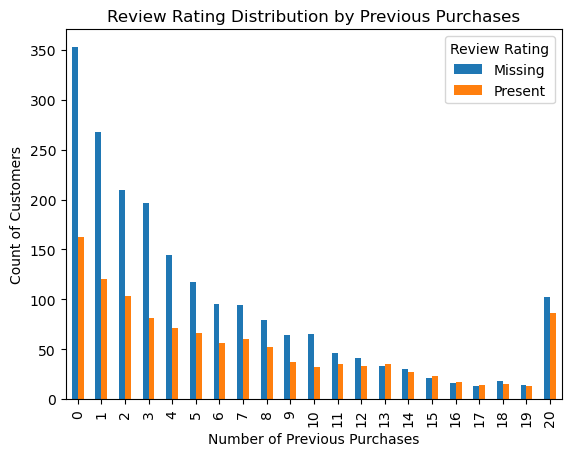

In [ ]:
review_data = shopping_data.pivot_table(columns="Review Rating", index="Previous Purchases", values="Purchase Amount (USD)", aggfunc='count')

review_data.plot(kind='bar')

plt.title('Review Rating by Previous Purchases')
plt.xlabel('Number of Previous Purchases')
plt.ylabel('Count of Customers')
plt.show()

Interpretation: Users leave reviews more when the item was purchased for the first time. After the number of purchases increase the number of reviews start to decrease until we reach the highest number of pruchases (20) and the reviews amount increases suddenly, which may indicate loyalty customers. 

Question #5
- Does gender determine the likelihood of what product the customer will buy?

In [82]:
shopping_data.pivot_table(columns="Gender",  values="Purchase Amount (USD)", index="Item Purchased", aggfunc='count')

Gender,Female,Male,Non-binary
Item Purchased,,,
Backpack,97.0,86.0,2.0
Belt,9.0,16.0,NaN
Boots,60.0,73.0,1.0
Dress,112.0,115.0,1.0
Gloves,83.0,96.0,1.0
Handbag,109.0,108.0,3.0
Hoodie,74.0,86.0,3.0
Jacket,65.0,67.0,2.0
Jeans,17.0,29.0,NaN


Interpretation: Based on the data, there is no visible correlation between the Gender and the likelihood of what product they will buy. The highest item purchased for women it's shorts, while for men it's sunglasses. However the amount of purchases for both men and women of shorts and sunglasses is not a huge difference. The difference in purchase for shorts between men and women is 6 purchases while the difference for Sunglasses is 13 purchases. This makes the corrlation between gender and item purchases visibly weak. 

Question #6
- Does seasonality increase the purchase amounts?

In [152]:
shopping_data.pivot_table(  values="Purchase Amount (USD)", index="Season", aggfunc='count')

,Purchase Amount (USD)
Season,
Fall,872
Spring,477
Summer,765
Winter,1044


Interpretation: The most purchase amounts were made in the Winter, then follwed was Fall, the Summer, then Spring. With Winter being the coldest season in the U.S, this could prompt users to buy more layers of clothing. Meanwhile Spring will just consist of some winter clothes and a few warm clothes. The shift from Summer to Fall will also cause users to buy more layers of clothing, increasing the purchase amounts. 

Question #7
- Does the seasons have an effect on the shipping type?

In [112]:
shipping_trends = shopping_data.groupby(['Season', 'Shipping Type']).size().reset_index(name='Count')
print(shipping_trends)

    Season   Shipping Type  Count
0     Fall  2-Day Shipping    265
1     Fall         Express     57
2     Fall    Next Day Air     72
3     Fall        Standard    478
4   Spring  2-Day Shipping    145
5   Spring         Express     41
6   Spring    Next Day Air     36
7   Spring        Standard    255
8   Summer  2-Day Shipping    229
9   Summer         Express     49
10  Summer    Next Day Air     54
11  Summer        Standard    433
12  Winter  2-Day Shipping    314
13  Winter         Express     78
14  Winter    Next Day Air     61
15  Winter        Standard    590
16  Winter    Store Pickup      1


Interpretation: We see that he shipping types are at its hightes during the Winter time. especially the express and 2-day shipping. The next day air shipping is popular in the Fall, and the store pickup is extremley uncommon, which can be seen as the outlier in this case. Standard shipping is the popular option over all others, however the other options may increase or decrease based on the season and weather. 

Question #8
- Does the customer age have an effect on what product they purchase?

In [114]:
under_30 = shopping_data[shopping_data['Age'] < 30]

print(under_30['Item Purchased'].value_counts())

Item Purchased
Sunglasses       100
Shorts            98
Handbag           92
Running Shoes     86
Pajamas           81
T-shirt           80
Leggings          77
Backpack          70
Dress             70
Gloves            70
Socks             69
Sweater           68
Scarf             59
Hoodie            56
Jacket            49
Boots             37
Jeans             15
Belt               9
Name: count, dtype: int64


In [110]:
over_30 = shopping_data[shopping_data['Age'] > 30]

print(over_30['Item Purchased'].value_counts())

Item Purchased
Shorts           154
Running Shoes    153
Sunglasses       152
Dress            152
Handbag          118
T-shirt          118
Gloves           109
Sweater          108
Backpack         106
Hoodie           103
Socks            101
Scarf             93
Boots             93
Leggings          92
Pajamas           88
Jacket            78
Jeans             28
Belt              15
Name: count, dtype: int64


Interpretation: The most bought item for users under 30 years old was sunglasses, while the most bought item for users over 30 years old was shorts. There's no exact indicator of what product a user will buy based on their age as both shorts and sunglasses are high in purchase amount for both age groups. 

Final Interpretations:
Answer Here: 